In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-01-31' #'2024-10-22'
sample =  'all' # 'randomsample500' 

## Read timeseries stats

In [3]:
metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-11-26.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [4]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Variable']]

In [5]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [6]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
full_table

49867
49867
56319
49867


,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,Type of Adopter,Granularity Numerical,Granularity,Average lifetime,Technology Lifetime,Strict replacement,Broad replacement,Feedstock,Category Type,Patent Category Name
0,exponential,curve_fit,True,0.487690,0.481543,7.392699e+03,7.694435e+03,1.051031,100.391781,0.010812,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
1,linear,curve_fit,True,0.406591,0.401862,8.497110e+03,8.730111e+03,1.528609,-1800.686448,1.014233,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
2,logistic,curve_fit,True,0.706834,0.703316,4.230428e+03,4.403095e+03,0.760129,289.208416,0.201153,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
3,gompertz,curve_fit,True,0.699004,0.695392,4.343411e+03,4.520689e+03,0.784392,287.769584,0.171707,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
4,softplus,curve_fit,True,0.513636,0.507799,7.018306e+03,7.304761e+03,0.880879,2.500417,0.090887,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56314,softplus,curve_fit,True,0.939718,0.909578,1.087347e+09,1.149038e+09,0.243888,39833.928174,1.002135,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56315,logistic-linear-cont,curve_fit,True,0.943906,0.915858,1.011818e+09,1.069223e+09,0.217256,260854.368598,0.613273,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56316,bass,curve_fit,True,0.924427,0.863968,1.533574e+09,1.636693e+09,0.324492,0.000001,0.008213,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56317,bertalanffy,curve_fit,True,0.954790,0.932185,8.154841e+08,8.617504e+08,0.314927,361745.557682,0.342127,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions


In [7]:
# correct internally inconsistent labels
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [8]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)

In [9]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flat', 'technology', 'Technology Name',
       'd', 'd_std', 'error_type', 'error_msg', 'n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name', 'ID',
       'Spatial Scale', 'Region', 'Country Name', 'Metric', 'Unit',
       'Data Source', 'Variable', 'Material Use Numeric

# Compute means of groups by functional form and statistical properties

In [10]:
pd.options.display.float_format = '{:.2f}'.format

In [11]:
full_table['dy_trend_slope_sign'] = np.sign(full_table['dy_trend_slope']) * (full_table['dy_trend_pval'] < 0.05)
full_table['dy_trend_slope_sign'].value_counts()

dy_trend_slope_sign
0.00     35026
1.00      8217
-1.00     6624
Name: count, dtype: int64

In [12]:
plot_table = full_table[(full_table["adj_r_squared"] > 0) & (full_table["adj_r_squared"] <= 1)]
plot_table.groupby(['dy_trend_slope_sign', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
dy_trend_slope_sign,,,,,,,,,
-1.00,0.77,0.79,0.40,0.80,0.45,0.81,0.46,0.81,0.46
0.00,0.65,0.71,0.58,0.71,0.55,0.71,0.62,0.72,0.62
1.00,0.69,0.93,0.94,0.96,0.71,0.96,0.96,0.96,0.96


In [13]:
full_table['ar_high_low'] = full_table['ar1'].apply(lambda x: 'high' if x > 0.9 else 'low')
full_table['ar_high_low'].value_counts()

ar_high_low
high    28734
low     21133
Name: count, dtype: int64

In [14]:
plot_table = full_table[(full_table["adj_r_squared"] > 0) & (full_table["adj_r_squared"] <= 1)]
plot_table.groupby(['ar_high_low', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
ar_high_low,,,,,,,,,
high,0.76,0.87,0.75,0.89,0.70,0.89,0.80,0.89,0.80
low,0.51,0.56,0.36,0.55,0.34,0.56,0.38,0.56,0.38


In [15]:
full_table['roughness_high_low'] = full_table['roughness'].apply(lambda x: 'high' if x > 0.5 else 'low')
full_table['roughness_high_low'].value_counts()

roughness_high_low
low     29237
high    20630
Name: count, dtype: int64

In [16]:
plot_table = full_table[(full_table["adj_r_squared"] > 0) & (full_table["adj_r_squared"] <= 1)]
plot_table.groupby(['roughness_high_low', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
roughness_high_low,,,,,,,,,
high,0.62,0.68,0.55,0.67,0.52,0.68,0.59,0.68,0.59
low,0.71,0.82,0.69,0.83,0.60,0.84,0.73,0.84,0.73


In [17]:
full_table['ts_length'] = (full_table['n'] >= 40)
full_table['ts_length'].value_counts()

ts_length
False    28420
True     21447
Name: count, dtype: int64

In [18]:
plot_table = full_table[(full_table["adj_r_squared"] > 0) & (full_table["adj_r_squared"] <= 1)]
plot_table.groupby(['ts_length', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
ts_length,,,,,,,,,
False,0.66,0.76,0.63,0.76,0.54,0.76,0.66,0.76,0.66
True,0.69,0.78,0.64,0.79,0.60,0.79,0.68,0.79,0.68


In [19]:
full_table['lastm_convexity_sign'].value_counts()

lastm_convexity_sign
1.00     24813
-1.00    15119
0.00      9935
Name: count, dtype: int64

In [20]:
full_table[full_table['lastm_convexity_pvalue'] < 0.33]['lastm_convexity_sign'].value_counts()

lastm_convexity_sign
1.00     24714
-1.00    14975
Name: count, dtype: int64

In [21]:
plot_table.groupby(['lastm_convexity_sign', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
lastm_convexity_sign,,,,,,,,,
-1.00,0.60,0.64,0.39,0.64,0.41,0.65,0.44,0.65,0.44
0.00,0.66,0.70,0.46,0.69,0.45,0.69,0.50,0.70,0.50
1.00,0.72,0.85,0.77,0.86,0.68,0.86,0.81,0.86,0.81


In [22]:
# position of maximum always at the end because data has been cut at maximum
full_table['y_max_rel_pos_near_end'] = (full_table['y_max_rel_pos'] > 0.95)
full_table['y_max_rel_pos_near_end'].value_counts()

y_max_rel_pos_near_end
False    34773
True     15094
Name: count, dtype: int64

In [23]:
plot_table = full_table[(full_table["adj_r_squared"] > 0) & (full_table["adj_r_squared"] <= 1)]
plot_table.groupby(['y_max_rel_pos_near_end', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
y_max_rel_pos_near_end,,,,,,,,,
False,0.64,0.69,0.48,0.69,0.47,0.70,0.53,0.70,0.53
True,0.73,0.89,0.87,0.91,0.74,0.91,0.90,0.91,0.90


In [24]:
# no drop after max because data has been cut after maximum
full_table['y_pct_mean_drop_after_max_hl'] = (full_table['y_pct_mean_drop_after_max'] > 5)
full_table['y_pct_mean_drop_after_max_hl'].value_counts()

y_pct_mean_drop_after_max_hl
False    26902
True     22965
Name: count, dtype: int64

## Using Jenna's metadata

In [25]:
plot_table.groupby(['Granularity', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
Granularity,,,,,,,,,
High,0.67,0.77,0.54,0.75,0.48,0.75,0.57,0.75,0.57
Low,0.66,0.74,0.67,0.77,0.60,0.77,0.72,0.77,0.72
Medium,0.83,0.91,0.84,0.92,0.80,0.92,0.89,0.92,0.89


In [26]:
plot_table.groupby(['Technology Lifetime', 'functional_form'])['adj_r_squared'].mean().unstack()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
Technology Lifetime,,,,,,,,,
Decades,0.67,0.76,0.68,0.78,0.61,0.79,0.72,0.78,0.72
Months,0.63,0.69,0.40,0.66,0.41,0.66,0.44,0.67,0.44
Years,0.72,0.83,0.73,0.84,0.62,0.84,0.76,0.84,0.77


Text(9.444444444444445, 0.5, '')

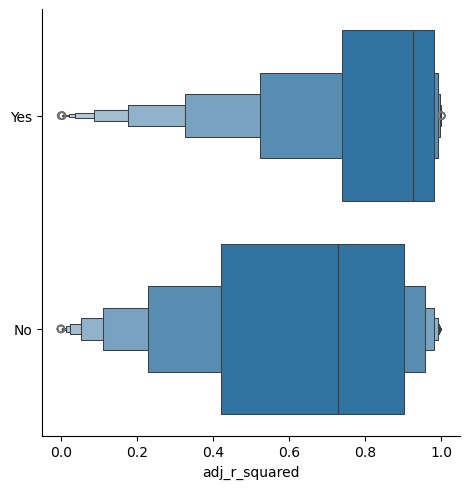

In [27]:
# distribution of adj r squared

sns.catplot(y='Broad replacement', x='adj_r_squared', #hue='functional_form',
            data=plot_table,
            kind='boxen', legend=False)
plt.ylabel('')

#if save_fig:
#    plt.savefig(f'figures/{sample}_{day}_adj_r_squared_dist.png', **savefig_settings)

## Look at fingerprints of good vs. bad fits

In [28]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flat', 'technology', 'Technology Name',
       'd', 'd_std', 'error_type', 'error_msg', 'n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name', 'ID',
       'Spatial Scale', 'Region', 'Country Name', 'Metric', 'Unit',
       'Data Source', 'Variable', 'Material Use Numeric

In [29]:
full_table['good_fit'] = (full_table['adj_r_squared'] > 0.9)

In [30]:
full_table.groupby('functional_form')['good_fit'].value_counts(normalize=True).unstack(level=0)

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
good_fit,,,,,,,,,
False,0.84,0.67,0.80,0.62,0.89,0.61,0.73,0.62,0.73
True,0.16,0.33,0.20,0.38,0.11,0.39,0.27,0.38,0.27


In [31]:
full_table['y_trend_slope_normalized'] = full_table['y_trend_slope'] / full_table['y_max']

In [32]:
pd.options.display.float_format = '{:.4f}'.format
full_table.groupby(['functional_form', 'good_fit'])['y_trend_slope_normalized'].mean().unstack(level=0)

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
good_fit,,,,,,,,,
False,0.0130,0.0081,0.0115,0.0064,0.0132,0.0061,0.0094,0.0063,0.0094
True,0.0260,0.0290,0.0287,0.0293,0.0303,0.0293,0.0304,0.0278,0.0304


# Correlation of goodness of fit between functional forms

In [33]:
r2_vals = full_table.pivot(index='technology', columns='functional_form', values='r_squared')
r2_vals.corr()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0000,0.7877,0.5219,0.6874,0.0019,0.6530,0.7287,0.6829,0.9158
bertalanffy,0.7877,1.0000,0.8128,0.9804,-0.0001,0.9674,0.7384,0.3630,0.7108
exponential,0.5219,0.8128,1.0000,0.8412,-0.0004,0.8436,0.6310,0.0796,0.4184
gompertz,0.6874,0.9804,0.8412,1.0000,-0.0005,0.9983,0.7796,0.1731,0.5669
linear,0.0019,-0.0001,-0.0004,-0.0005,1.0000,0.0002,-0.0007,0.0273,0.1651
logistic,0.6530,0.9674,0.8436,0.9983,0.0002,1.0000,0.7862,0.1159,0.5206
logistic-linear-cont,0.7287,0.7384,0.6310,0.7796,-0.0007,0.7862,1.0000,-0.0003,0.4369
richards,0.6829,0.3630,0.0796,0.1731,0.0273,0.1159,-0.0003,1.0000,0.8734
softplus,0.9158,0.7108,0.4184,0.5669,0.1651,0.5206,0.4369,0.8734,1.0000


In [34]:
r2adj_vals = full_table.pivot(index='technology', columns='functional_form', values='adj_r_squared')
r2adj_vals.corr()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0000,0.7871,0.4967,0.6826,0.0021,0.6466,0.7164,0.6961,0.9211
bertalanffy,0.7871,1.0000,0.7766,0.9796,-0.0001,0.9659,0.7358,0.3712,0.7122
exponential,0.4967,0.7766,1.0000,0.8046,-0.0003,0.8070,0.6035,0.0781,0.3977
gompertz,0.6826,0.9796,0.8046,1.0000,-0.0005,0.9982,0.7790,0.1775,0.5644
linear,0.0021,-0.0001,-0.0003,-0.0005,1.0000,0.0002,-0.0007,0.0242,0.1494
logistic,0.6466,0.9659,0.8070,0.9982,0.0002,1.0000,0.7859,0.1189,0.5166
logistic-linear-cont,0.7164,0.7358,0.6035,0.7790,-0.0007,0.7859,1.0000,-0.0003,0.4294
richards,0.6961,0.3712,0.0781,0.1775,0.0242,0.1189,-0.0003,1.0000,0.8801
softplus,0.9211,0.7122,0.3977,0.5644,0.1494,0.5166,0.4294,0.8801,1.0000


In [46]:
pd.set_option('display.precision', 1)

In [56]:
r2_vals = full_table.pivot(index='technology', columns='functional_form', values='r_squared')
ff_order = ['linear', 'logistic', 'gompertz', 'bertalanffy', 'richards', 'bass', 'exponential', 'logistic-linear-cont', 'softplus']
r2_corr = r2_vals[ff_order].corr(method='spearman')
r2_corr

functional_form,linear,logistic,gompertz,bertalanffy,richards,bass,exponential,logistic-linear-cont,softplus
functional_form,,,,,,,,,
linear,1.0000,0.6766,0.6680,0.7096,0.6797,0.6840,0.7823,0.7952,0.7977
logistic,0.6766,1.0000,0.9795,0.9481,0.9926,0.8018,0.8688,0.8904,0.8939
gompertz,0.6680,0.9795,1.0000,0.9337,0.9767,0.7870,0.8604,0.8836,0.8853
bertalanffy,0.7096,0.9481,0.9337,1.0000,0.9462,0.8473,0.8328,0.8535,0.8580
richards,0.6797,0.9926,0.9767,0.9462,1.0000,0.8111,0.8638,0.8861,0.8897
bass,0.6840,0.8018,0.7870,0.8473,0.8111,1.0000,0.6579,0.6758,0.6799
exponential,0.7823,0.8688,0.8604,0.8328,0.8638,0.6579,1.0000,0.9855,0.9883
logistic-linear-cont,0.7952,0.8904,0.8836,0.8535,0.8861,0.6758,0.9855,1.0000,0.9923
softplus,0.7977,0.8939,0.8853,0.8580,0.8897,0.6799,0.9883,0.9923,1.0000


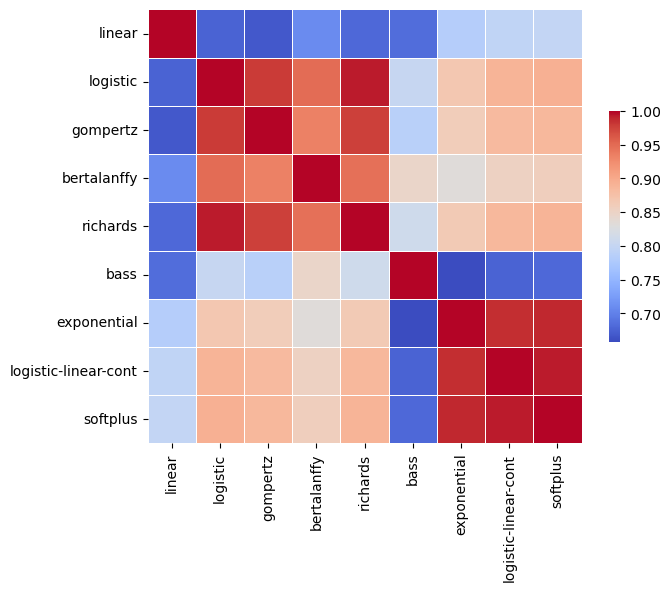

In [57]:
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(r2_corr, dtype=bool))

import matplotlib.colors as colors

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(7, 6))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(r2_corr, cmap='coolwarm',
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.ylabel('')
plt.xlabel('')

if save_fig:
    plt.savefig('figures/r2_rank_correlation.png', **savefig_settings)

In [35]:
# using the ranking from BIC and MCp

full_table['BIC_rank'] = full_table.groupby('technology')['BIC'].rank(method='min')
full_table['MCp_rank'] = full_table.groupby('technology')['MCp'].rank(method='min')
full_table['aRS_rank'] = full_table.groupby('technology')['adj_r_squared'].rank(method='min', ascending=False)

In [36]:
bicrank_vals = full_table.pivot(index='technology', columns='functional_form', values='BIC_rank')
bicrank_vals.corr()

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0000,0.5018,-0.6107,0.3600,-0.0739,0.1157,-0.7139,0.3433,-0.6821
bertalanffy,0.5018,1.0000,-0.5540,0.3008,0.0102,-0.1330,-0.5270,0.0994,-0.4981
exponential,-0.6107,-0.5540,1.0000,-0.6056,0.2612,-0.3629,0.5739,-0.6578,0.4789
gompertz,0.3600,0.3008,-0.6056,1.0000,-0.2706,0.1654,-0.5053,0.4210,-0.3958
linear,-0.0739,0.0102,0.2612,-0.2706,1.0000,-0.3983,-0.0192,-0.6997,-0.2010
logistic,0.1157,-0.1330,-0.3629,0.1654,-0.3983,1.0000,-0.3177,0.5310,-0.2759
logistic-linear-cont,-0.7139,-0.5270,0.5739,-0.5053,-0.0192,-0.3177,1.0000,-0.3826,0.6495
richards,0.3433,0.0994,-0.6578,0.4210,-0.6997,0.5310,-0.3826,1.0000,-0.2298
softplus,-0.6821,-0.4981,0.4789,-0.3958,-0.2010,-0.2759,0.6495,-0.2298,1.0000


In [37]:
mcp_rank_vals = full_table.pivot(index='technology', columns='functional_form', values='MCp_rank')
mcp_rank_vals.corr(method='pearson')

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0000,0.5029,-0.6149,0.3397,-0.0490,0.0879,-0.7134,0.3224,-0.6794
bertalanffy,0.5029,1.0000,-0.5470,0.2942,0.0160,-0.1492,-0.5235,0.0937,-0.5009
exponential,-0.6149,-0.5470,1.0000,-0.5925,0.2641,-0.3470,0.5769,-0.6641,0.4870
gompertz,0.3397,0.2942,-0.5925,1.0000,-0.2470,0.1407,-0.5016,0.3999,-0.3927
linear,-0.0490,0.0160,0.2641,-0.2470,1.0000,-0.3938,-0.0132,-0.7062,-0.2113
logistic,0.0879,-0.1492,-0.3470,0.1407,-0.3938,1.0000,-0.3097,0.5265,-0.2736
logistic-linear-cont,-0.7134,-0.5235,0.5769,-0.5016,-0.0132,-0.3097,1.0000,-0.3814,0.6485
richards,0.3224,0.0937,-0.6641,0.3999,-0.7062,0.5265,-0.3814,1.0000,-0.2155
softplus,-0.6794,-0.5009,0.4870,-0.3927,-0.2113,-0.2736,0.6485,-0.2155,1.0000


## Notes:

- Negative correlation of R2 and adj R2 of bass and very low for bertalanffy -> indication that fits are not working?
- High correlation between richards, gompertz, logistic -> similar types of dataseries are matching good
- High correlation between softplus and logistic-linear-cont -> similar types of dataseries are matching good

In [38]:
r2adj_vals.max()

functional_form
bass                   1.0000
bertalanffy            1.0000
exponential            1.0000
gompertz               1.0000
linear                 0.9979
logistic               1.0000
logistic-linear-cont   1.0000
richards               1.0000
softplus               1.0000
dtype: float64

/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/numpy/core/function_base.py:168: RuntimeWarning: invalid value encountered in add
  y += start
/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


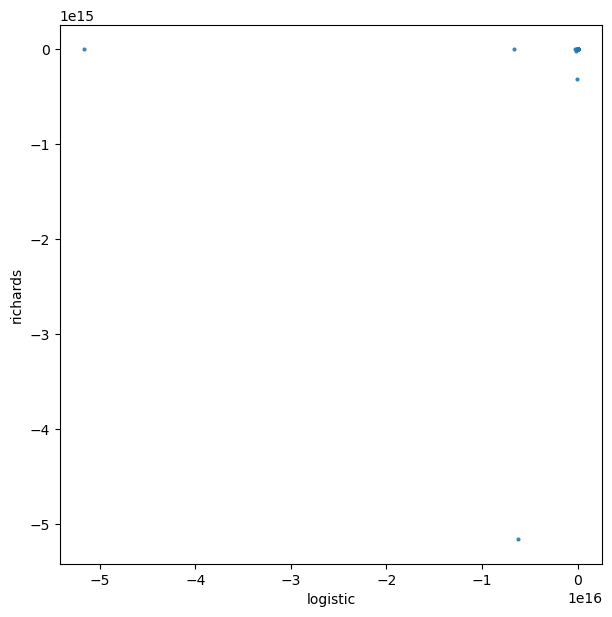

In [39]:
# plot one relationship (adj_r2)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
x_var = 'logistic'
y_var = 'richards'
sns.regplot(data=r2adj_vals, x=x_var, y=y_var, scatter_kws={'s': 4})
v_max = r2adj_vals[[x_var, y_var]].max().max()
plt.plot([0, v_max], [0, v_max])

In [40]:
(r2adj_vals < -1).sum()

functional_form
bass                    87
bertalanffy             80
exponential             58
gompertz                28
linear                  58
logistic                54
logistic-linear-cont    43
richards                54
softplus                58
dtype: int64

In [41]:
(r2adj_vals < -1).sum(axis=1).value_counts()

0    5429
1      56
8      34
7      15
9       8
2       3
3       1
6       1
Name: count, dtype: int64

In [42]:
# for R2 set all values smaller than 0 to 0
r2_vals = r2_vals.where(r2_vals > 0, 0)

# for adj R2 set all values smaller than -1 to -1
r2adj_vals = r2_vals.where(r2_vals > -1, -1)

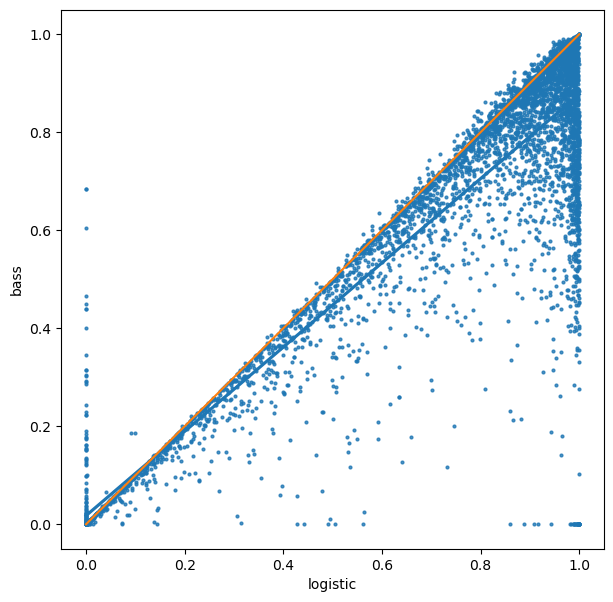

In [43]:
# plot one relationship (r2)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
x_var = 'logistic'
y_var = 'bass'
sns.regplot(data=r2_vals, x=x_var, y=y_var, scatter_kws={'s': 4})
v_max = r2adj_vals[[x_var, y_var]].max().max()
plt.plot([0, v_max], [0, v_max])

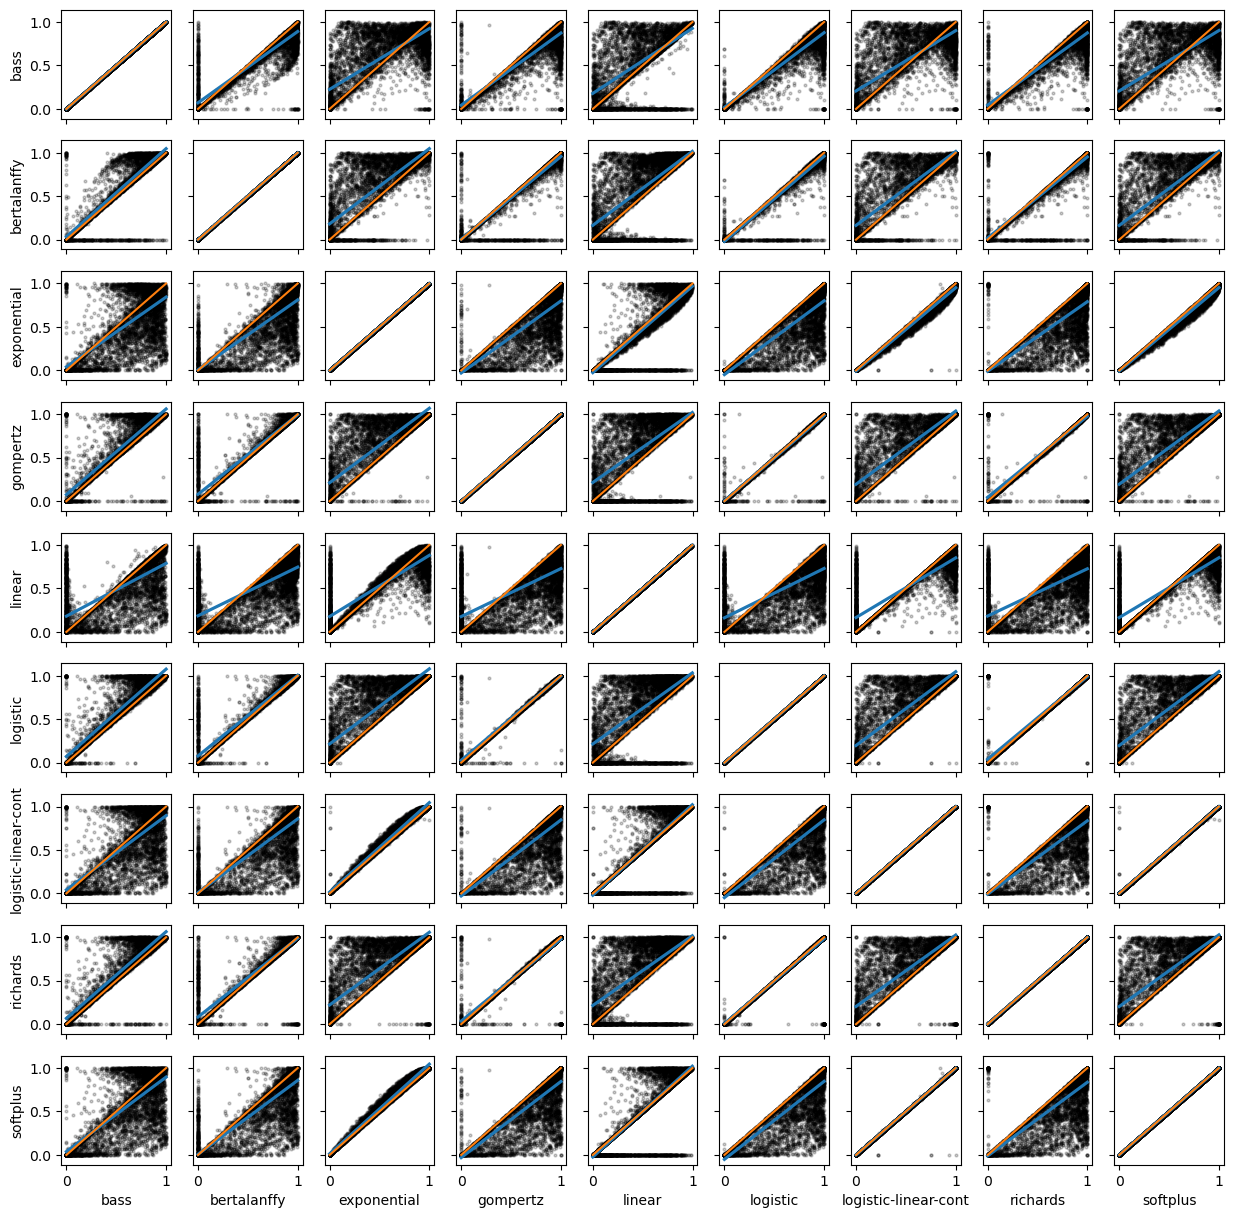

In [44]:
fig, axs = plt.subplots(len(r2adj_vals.columns), len(r2adj_vals.columns), figsize=(15, 15), sharex=True, sharey=True)

for i in range(len(r2adj_vals.columns)):
    y_var = r2adj_vals.columns[i]
    for j in range(len(r2adj_vals.columns)):
        x_var = r2adj_vals.columns[j]

        sns.regplot(data=r2adj_vals, x=x_var, y=y_var, ax=axs[i][j], scatter_kws={'s': 4, 'color': 'black', 'alpha': 0.2})
        v_max = r2adj_vals[[x_var, y_var]].max().max()
        # print(v_max)
        axs[i][j].plot([0, v_max], [0, v_max])
        if j > 0:
            axs[i][j].set_ylabel('')
        if (i + 1) < len(r2adj_vals.columns):
            axs[i][j].set_xlabel('')

if save_fig:
    fig.savefig('figures/linear_regressions_adjr2.png', **savefig_settings)

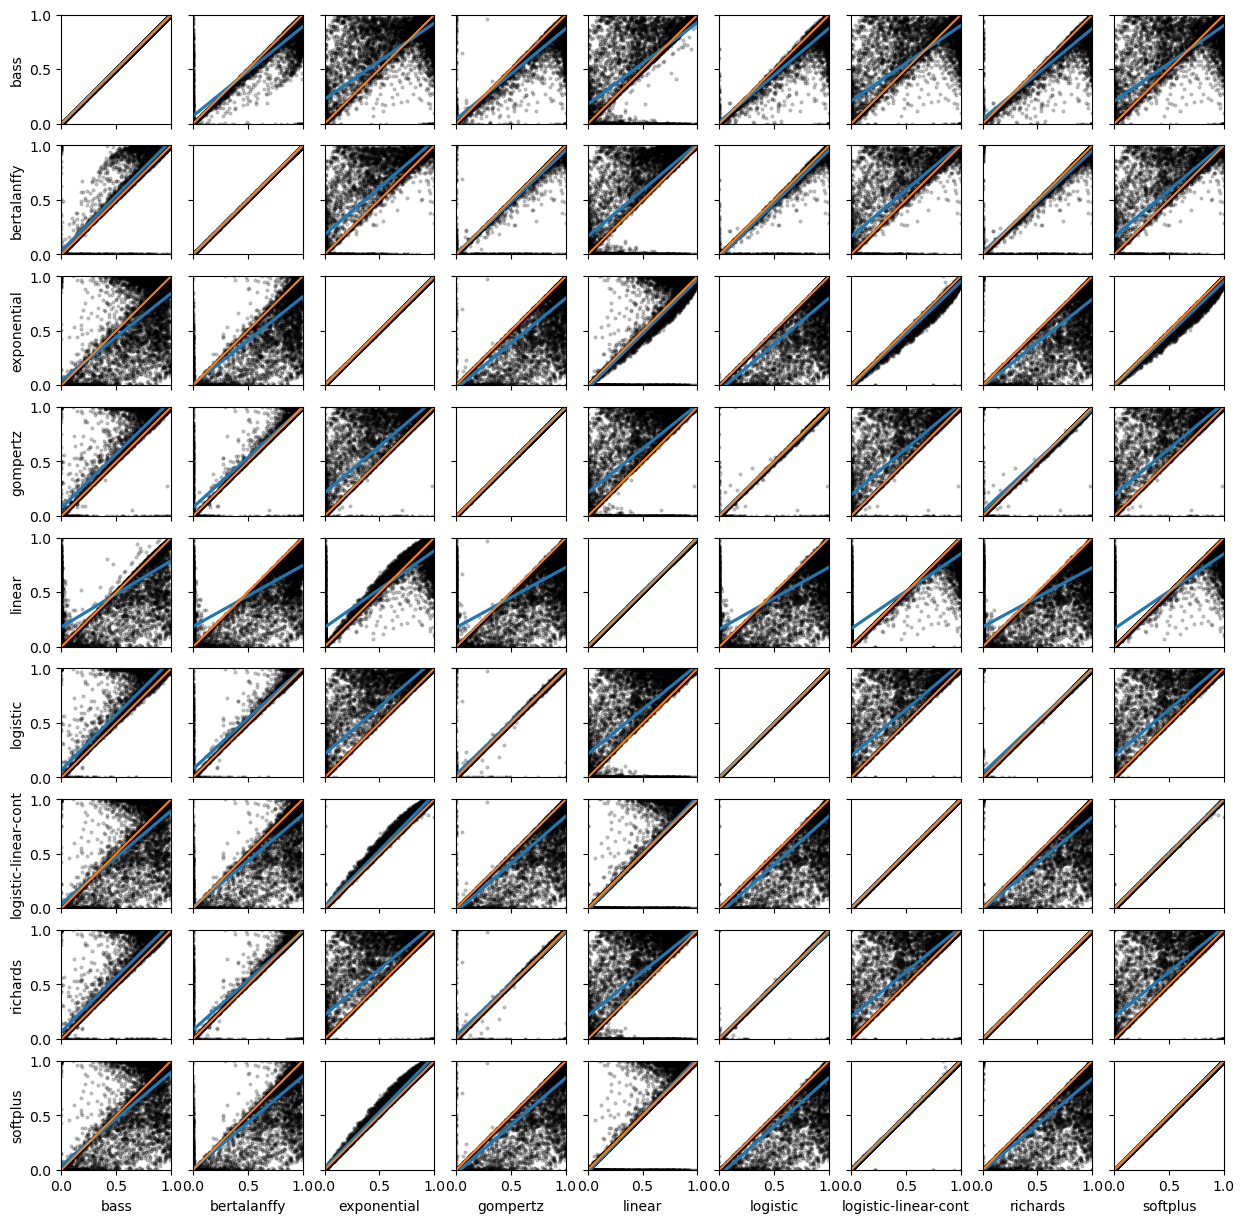

In [45]:
fig, axs = plt.subplots(len(r2adj_vals.columns), len(r2adj_vals.columns), figsize=(15, 15), sharex=True, sharey=True)

for i in range(len(r2_vals.columns)):
    y_var = r2_vals.columns[i]
    for j in range(len(r2_vals.columns)):
        x_var = r2_vals.columns[j]

        sns.regplot(data=r2_vals, x=x_var, y=y_var, ax=axs[i][j], scatter_kws={'s': 4, 'color': 'black', 'alpha': 0.2})
        #v_max = r2_vals[[x_var, y_var]].max().max()
        v_max = 1
        # print(v_max)
        axs[i][j].plot([0, v_max], [0, v_max])
        axs[i][j].set_xlim([0, v_max])
        axs[i][j].set_ylim([0, v_max])
        if j > 0:
            axs[i][j].set_ylabel('')
        if (i + 1) < len(r2_vals.columns):
            axs[i][j].set_xlabel('')

if save_fig:
    fig.savefig('figures/linear_regressions_r2.png', **savefig_settings)

# Position of fitted inflection point

percentage of ts with t_max < infl: 0.19722372453578507
percentage of ts with t_max < infl: 0.23742563547863715
percentage of ts with t_max < infl: 0.0
percentage of ts with t_max < infl: 0.20622497269748818


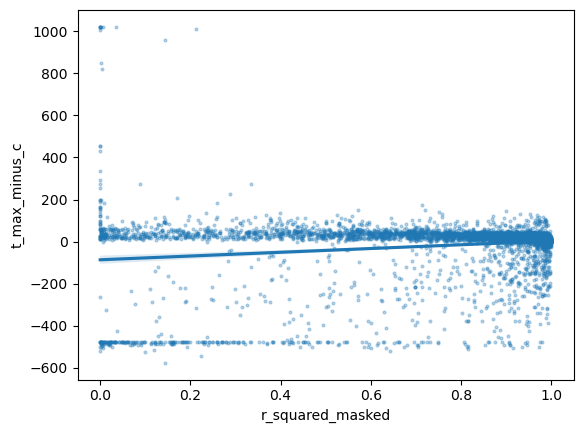

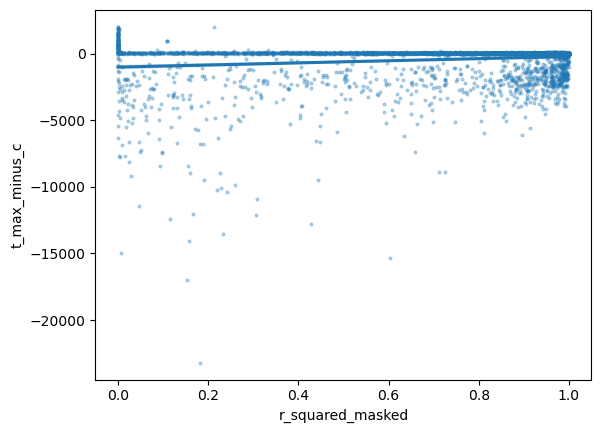

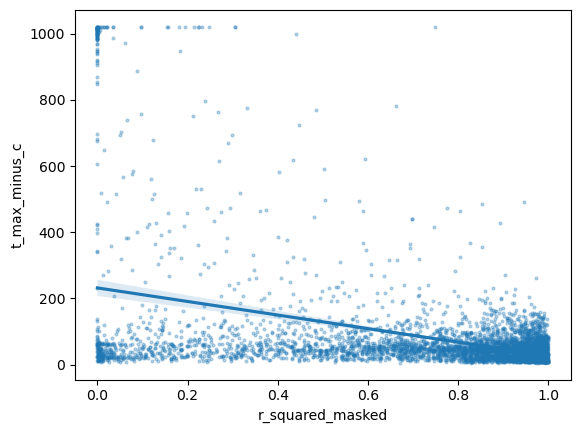

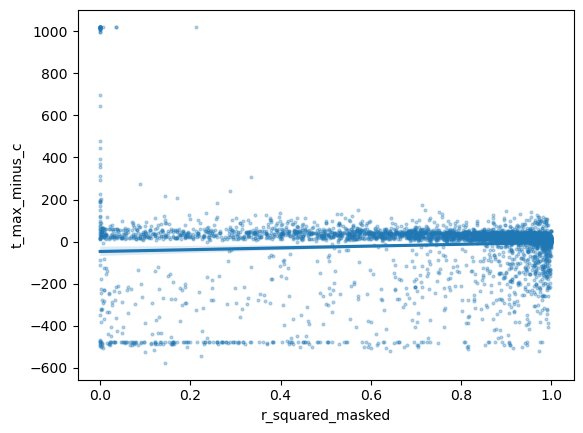

In [58]:
for func_form in ['logistic', 'gompertz', 'bertalanffy', 'richards']:

    fig, ax = plt.subplots(1, 1)
    
    gr_log = full_table[(full_table['functional_form'] == func_form)]
    print("percentage of ts with t_max < infl:", 1 - (gr_log['t_max'] > gr_log['c']).value_counts(normalize=True)[True])
    
    sns.regplot(data=gr_log.assign(t_max_minus_c = gr_log['t_max'] - gr_log['c']),
                y='t_max_minus_c', x='r_squared_masked', scatter_kws={'s': 4, 'alpha': 0.3}, ax=ax)
    
    if save_fig:
        plt.savefig(f'figures/{sample}_{day}_r_squared_over_inflection_pos_{func_form}.png', **savefig_settings)

In [59]:
(gr_log['t_max'] < gr_log['c']).value_counts(normalize=True)

False   0.7938
True    0.2062
Name: proportion, dtype: float64

In [60]:
# How many time series are at the boundary
# Dependency of the growth rate
# prefer to use an exponential in these cases -> is exponential fit better?

# Effect of filtering by r2 (> 0.95) on dataset by categories in Jenna's metadata

In [70]:
gr_log = full_table[(full_table['functional_form'] == 'logistic')].copy()
print(len(gr_log))
gr_logf = full_table[(full_table['functional_form'] == 'logistic') & (full_table['r_squared'] > 0.95)]
print(len(gr_logf))

5547
1638


In [71]:
# effect of filtering with r_squared > 0.95?
gr_log.assign(high_r2=(gr_log['r_squared'] > 0.95)).groupby('Type of Adopter')['high_r2'].value_counts(normalize=True).unstack()

high_r2,False,True
Type of Adopter,,
Both [3],0.4834,0.5166
Firms [1],0.7702,0.2298
Individuals [2],0.7510,0.2490


In [72]:
pct_high_r2_cat = 100 * gr_log.assign(high_r2=(gr_log['r_squared'] > 0.95)).groupby('Category Type')['high_r2'].value_counts(normalize=True).unstack()
pct_high_r2_cat

high_r2,False,True
Category Type,,
Appliances,12.7306,87.2694
Chemicals and Industrial,55.2632,44.7368
Digitalization,13.3333,86.6667
Energy Supply,57.1014,42.8986
Food and Health,87.1708,12.8292
Infrastructure,72.6562,27.3438
Materials,90.4930,9.5070
Sea and Water,83.4184,16.5816
Space and Defense,84.8485,15.1515


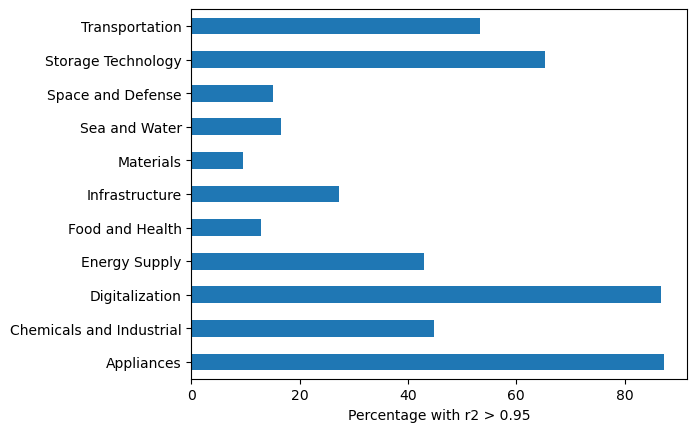

In [73]:
pct_high_r2_cat[True].plot.barh()
plt.ylabel('')
plt.xlabel('Percentage with r2 > 0.95')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_pct_high_r2_by_tech_cat.png', **savefig_settings)

In [74]:
pct_high_r2_metric = 100*gr_log.assign(high_r2=(gr_log['r_squared'] > 0.95)).groupby('Metric')['high_r2'].value_counts(normalize=True).unstack()
pct_high_r2_metric

high_r2,False,True
Metric,,
Annual Production,79.4393,20.5607
Computing Capacity,25.0000,75.0000
Cumulative Acreage,NaN,100.0000
Cumulative Length,65.3846,34.6154
Cumulative Rated Capacity,50.0000,50.0000
Cumulative Rated Power,25.0000,75.0000
Cumulative Total Capacity,62.3932,37.6068
Installed Capacity,NaN,100.0000
Installed electricity capacity,46.4135,53.5865


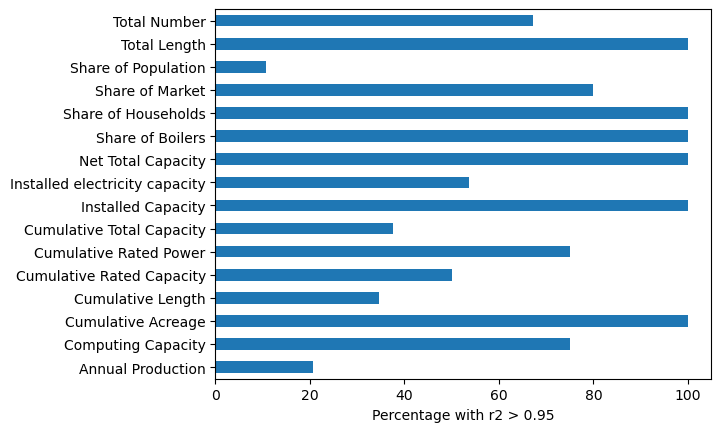

In [75]:
pct_high_r2_metric[True].plot.barh()
plt.ylabel('')
plt.xlabel('Percentage with r2 > 0.95')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_pct_high_r2_by_metric.png', **savefig_settings)

In [76]:
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
gr_log['metric_grouped'] = gr_log['Metric'].map(group_metrics)

In [80]:
pct_high_r2_metric_g = 100*gr_log.assign(high_r2=(gr_log['r_squared'] > 0.95)).groupby('metric_grouped')['high_r2'].value_counts(normalize=True).unstack()
pct_high_r2_metric_g

high_r2,False,True
metric_grouped,,
annual,79.4393,20.5607
cumulative,40.3654,59.6346
share,88.5526,11.4474


In [83]:
gr_log.groupby('metric_grouped')['functional_form'].count()

metric_grouped
annual        2033
cumulative    1697
share         1817
Name: functional_form, dtype: int64

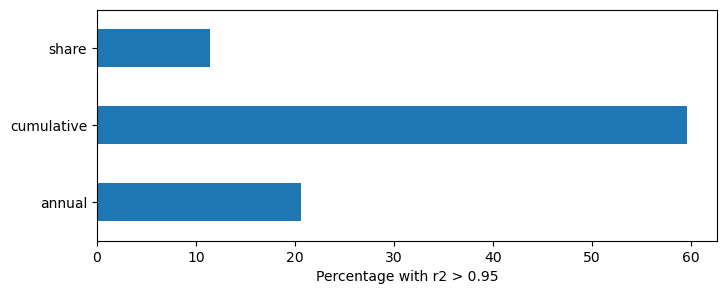

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
pct_high_r2_metric_g[True].plot.barh()
plt.ylabel('')
plt.xlabel('Percentage with r2 > 0.95')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_pct_high_r2_by_metric_grouped.png', **savefig_settings)

# Impact of 'metric' category on fit of different functional forms

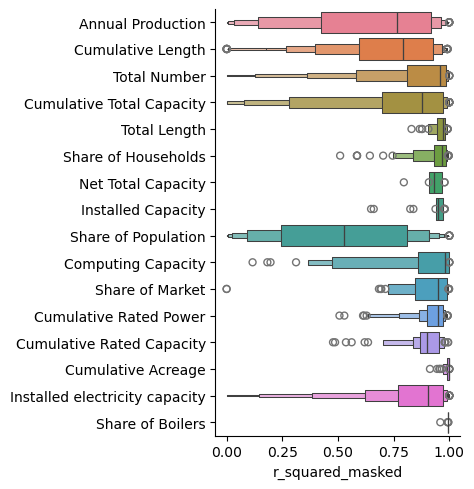

In [68]:
# distribution of r_squared for different functional forms

sns.catplot(y='Metric', x='r_squared_masked', hue='Metric',
            data=full_table, #full_table[(full_table['functional_form'].isin(['logistic', 'richards', 'softplus']))],
            kind='boxen', legend=False)
plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_dist_by_metric.png', **savefig_settings)

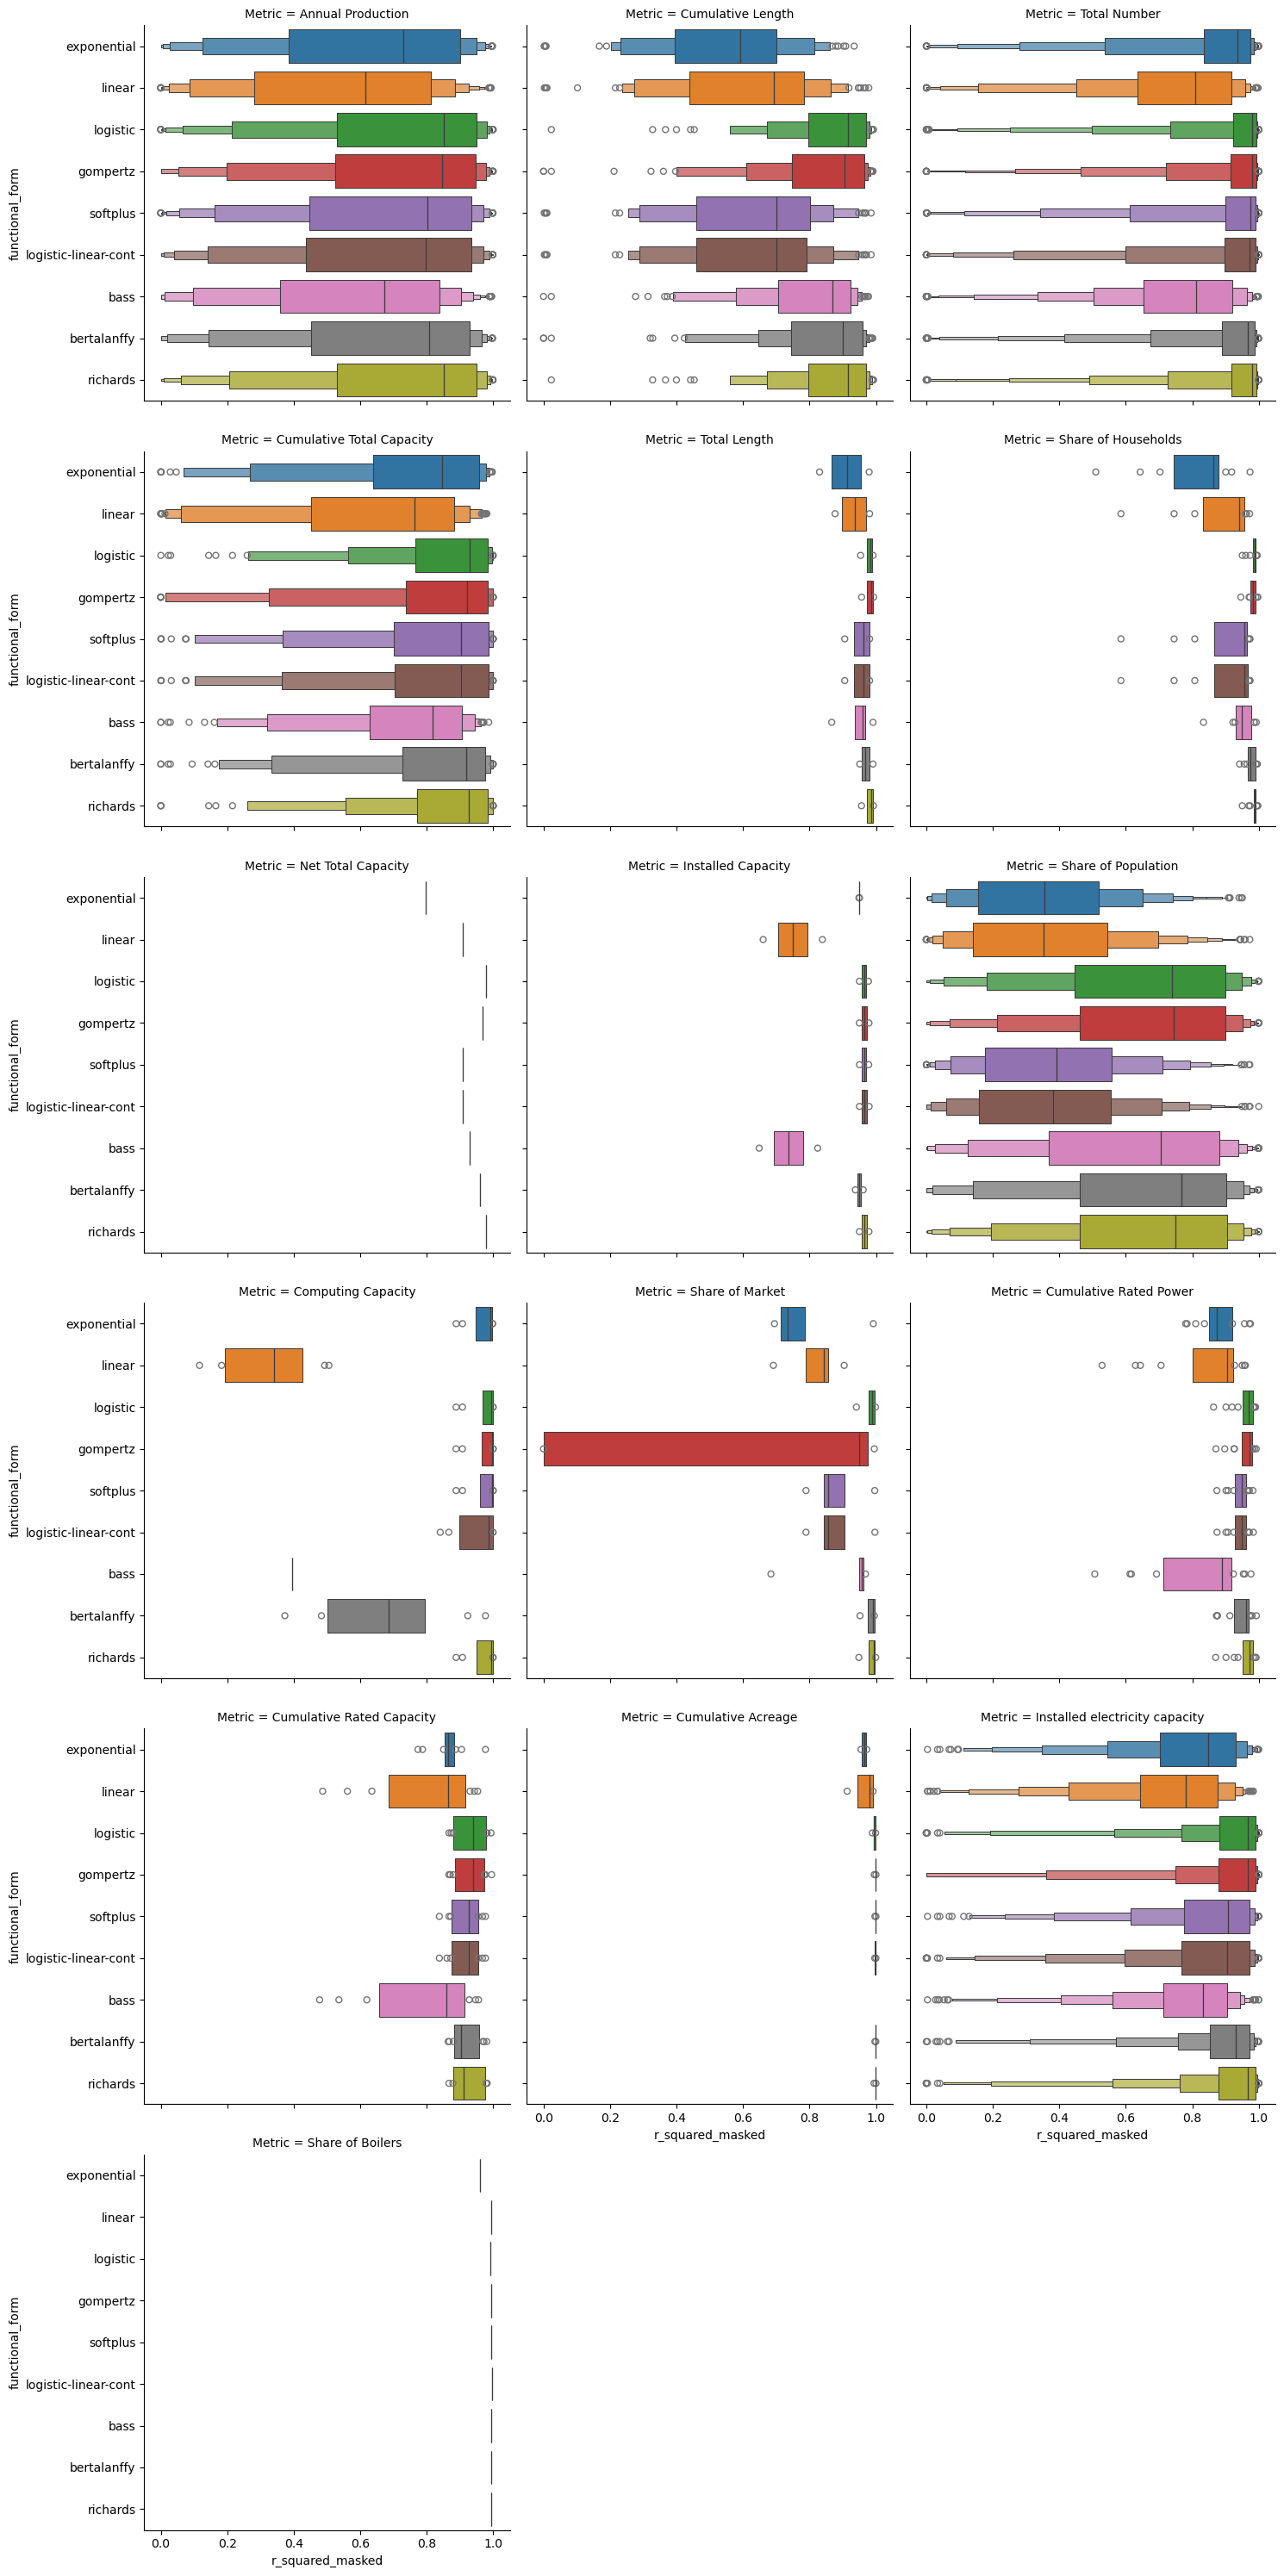

In [69]:
# distribution of r_squared for different functional forms

sns.catplot(y='functional_form', x='r_squared_masked', hue='functional_form', col='Metric', col_wrap=3,
            data=full_table, #full_table[(full_table['functional_form'].isin(['logistic', 'richards', 'softplus']))],
            kind='boxen', legend=False)
#plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_dist_by_metric_all.png', **savefig_settings)

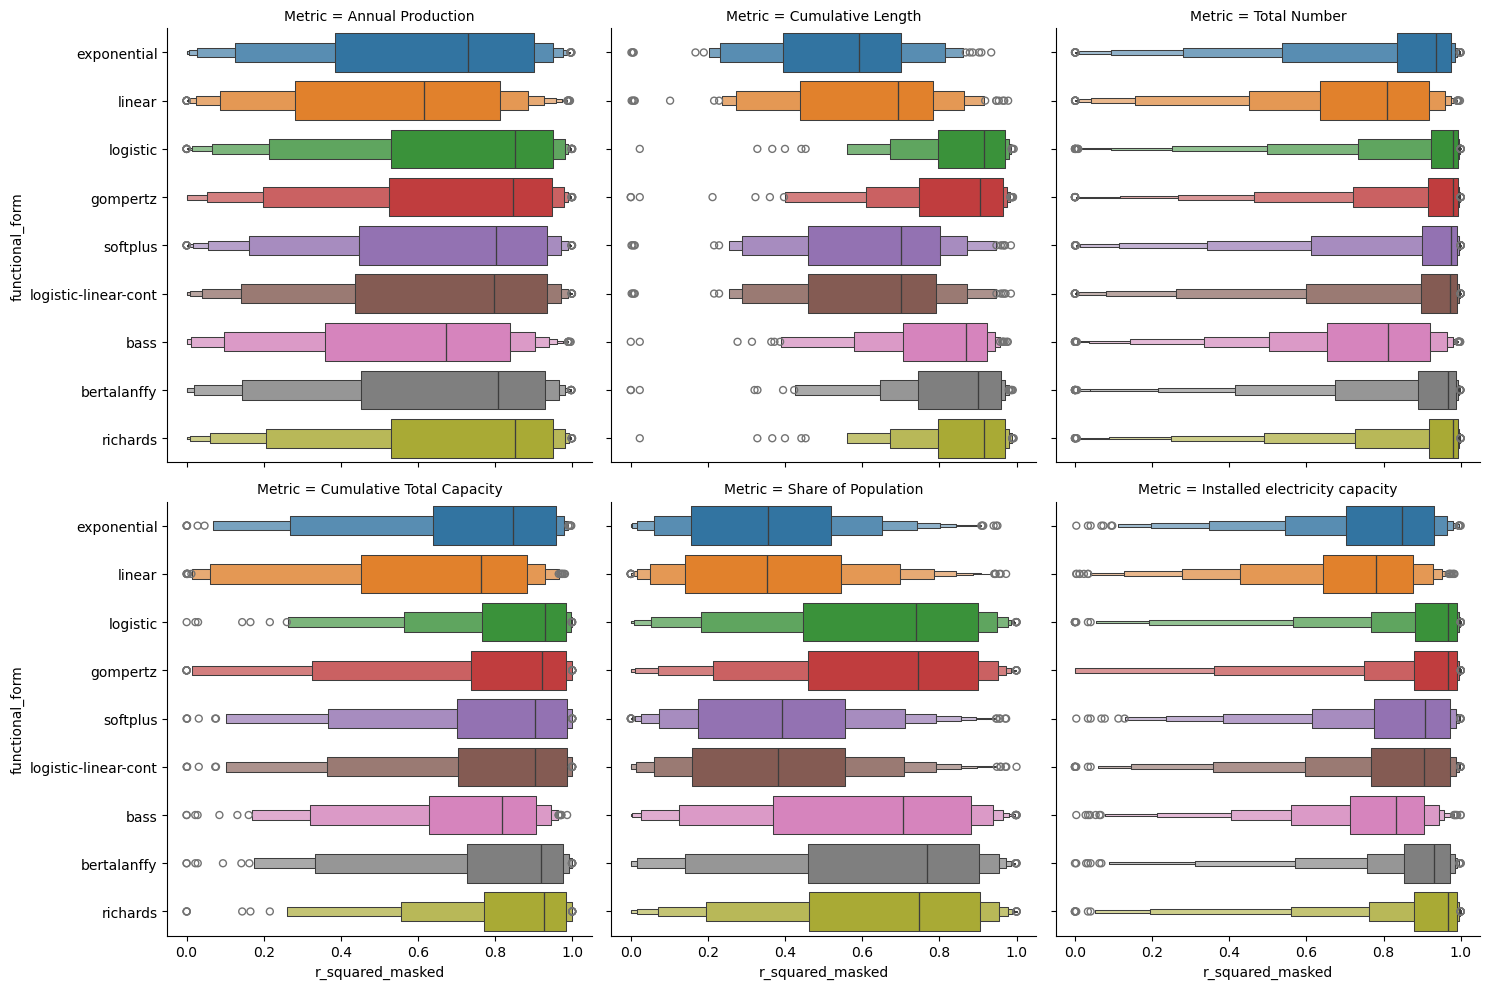

In [70]:
# filtered for better readability and display in presentations / papers

counts = full_table['Metric'].value_counts()
fmetrics = counts[counts > 150].index

sns.catplot(y='functional_form', x='r_squared_masked', hue='functional_form', col='Metric', col_wrap=3,
            data=full_table[full_table['Metric'].isin(fmetrics)], #full_table[(full_table['functional_form'].isin(['logistic', 'richards', 'softplus']))],
            kind='boxen', legend=False)
#plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_dist_by_metric_filtered.png', **savefig_settings)

In [71]:
ff_metric = full_table.groupby(['functional_form', 'Metric'])['r_squared_masked'].mean().unstack()
ff_metric

Metric,Annual Production,Computing Capacity,Cumulative Acreage,Cumulative Length,Cumulative Rated Capacity,Cumulative Rated Power,Cumulative Total Capacity,Installed Capacity,Installed electricity capacity,Net Total Capacity,Share of Boilers,Share of Households,Share of Market,Share of Population,Total Length,Total Number
functional_form,,,,,,,,,,,,,,,,
bass,0.5821,0.3944,NaN,0.7867,0.7817,0.8221,0.7156,0.7366,0.7699,0.9304,0.9947,0.9461,0.9044,0.6122,0.9442,0.7518
bertalanffy,0.6665,0.6732,0.9988,0.8184,0.9160,0.9455,0.7809,0.9497,0.8681,0.9601,0.9949,0.9755,0.9815,0.6502,0.9690,0.8751
exponential,0.6268,0.9660,0.9642,0.5455,0.8632,0.8806,0.7320,0.9495,0.7794,0.7958,0.9595,0.8114,0.7842,0.3545,0.9083,0.8341
gompertz,0.7010,0.9713,0.9981,0.8208,0.9313,0.9580,0.7818,0.9644,0.8722,0.9668,0.9945,0.9810,0.5841,0.6519,0.9799,0.8939
linear,0.5444,0.3225,0.9641,0.6018,0.7952,0.8403,0.6353,0.7497,0.7188,0.9082,0.9951,0.8784,0.8171,0.3630,0.9325,0.7317
logistic,0.7068,0.9717,0.9949,0.8476,0.9317,0.9585,0.8262,0.9638,0.8903,0.9786,0.9923,0.9824,0.9805,0.6445,0.9780,0.8967
logistic-linear-cont,0.6641,0.9479,0.9982,0.6220,0.9162,0.9420,0.7738,0.9648,0.8231,0.9084,0.9955,0.8939,0.8782,0.3769,0.9525,0.8635
richards,0.7059,0.9680,0.9978,0.8485,0.9274,0.9606,0.8258,0.9645,0.8888,0.9786,0.9943,0.9846,0.9833,0.6538,0.9799,0.8947
softplus,0.6714,0.9704,0.9987,0.6227,0.9164,0.9413,0.7737,0.9642,0.8306,0.9083,0.9952,0.8937,0.8781,0.3864,0.9525,0.8688


In [72]:
ff_metric.rank(ascending=False).fillna(-1).astype('int')

Metric,Annual Production,Computing Capacity,Cumulative Acreage,Cumulative Length,Cumulative Rated Capacity,Cumulative Rated Power,Cumulative Total Capacity,Installed Capacity,Installed electricity capacity,Net Total Capacity,Share of Boilers,Share of Households,Share of Market,Share of Population,Total Length,Total Number
functional_form,,,,,,,,,,,,,,,,
bass,8,8,-1,5,9,9,8,9,8,5,5,5,4,5,7,8
bertalanffy,5,7,1,4,6,4,4,6,4,4,4,4,2,3,4,4
exponential,7,5,7,9,7,7,7,7,7,9,9,9,8,9,9,7
gompertz,3,2,4,3,2,3,3,3,3,3,6,3,9,2,1,3
linear,9,9,8,8,8,8,9,8,9,8,3,8,7,8,8,9
logistic,1,1,6,2,1,2,1,5,1,1,8,2,3,4,3,1
logistic-linear-cont,6,6,3,7,5,5,5,1,6,6,1,6,5,7,5,6
richards,2,4,5,1,3,1,2,2,2,2,7,1,1,1,2,2
softplus,4,3,2,6,4,6,6,4,5,7,2,7,6,6,6,5


## Group similar 'metrics' together

In [73]:
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}

In [74]:
full_table[full_table['Metric'] == 'Total Number']['Technology Name'].unique()

array(['Radio', 'Telegraph Traffic', 'Postal Traffic', 'Telephones',
       'Passenger Cars', 'Space Launches', 'Nuclear Weapons',
       'Television', 'Crop Harvester', 'Cellphones'], dtype=object)

In [75]:
full_table[full_table['Metric'] == 'Cumulative Total Capacity']['Technology Name'].unique()

array(['Bicycles', 'Steamships', 'Motorcycles', 'Passenger Cars',
       'Natural Gas Power', 'Coal Power', 'Refrigerators',
       'Washing Machines', 'Laundry Dryers', 'High-Speed Rail',
       'Oil Refining Capacity', 'Jet Aircraft', 'Cellphones',
       'Wet Flue Gas Desulfurization Systems', 'Stationary Steam Engines',
       'Electric Bicycles', 'Compact Fluorescent Light Bulbs',
       'Steam Locomotives'], dtype=object)

In [76]:
full_table[full_table['Metric'] == 'Cumulative Rated Capacity']['Technology Name'].unique()

array(['Pumped Hydro Storage', 'Latent Heat Storage',
       'Lead-Acid Battery Storage', 'Sensible Heat Storage',
       'Lithium-Ion Battery Storage', 'Sodium-Based Battery Storage',
       'Flywheel Battery Storage'], dtype=object)

In [77]:
full_table['metric_grouped'] = full_table['Metric'].map(group_metrics)

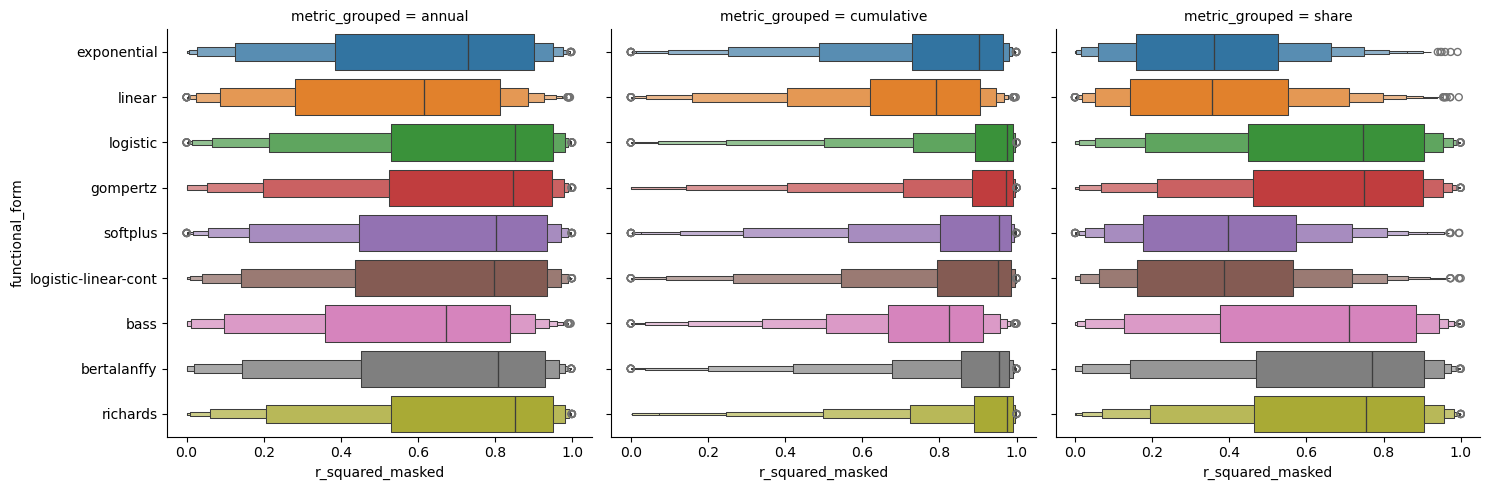

In [78]:
# distribution of r_squared for different functional forms

sns.catplot(y='functional_form', x='r_squared_masked', hue='functional_form', col='metric_grouped', col_wrap=3,
            data=full_table, #full_table[(full_table['functional_form'].isin(['logistic', 'richards', 'softplus']))],
            kind='boxen', legend=False)
#plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_dist_by_metric_grouped.png', **savefig_settings)

Note: Differences in "share" makes sense: high gof for s-shaped functional forms, lower for other

In [79]:
full_table[full_table['r_squared_masked'].notna()]['metric_grouped'].value_counts()

metric_grouped
annual        15421
cumulative    14249
share         13813
Name: count, dtype: int64

In [80]:
# rank of mean r_squared
ff_metric = full_table.groupby(['functional_form', 'metric_grouped'])['r_squared_masked'].mean().unstack()
ff_metric.rank(ascending=False).fillna(-1).astype('int')

metric_grouped,annual,cumulative,share
functional_form,,,
bass,8,8,5
bertalanffy,5,4,3
exponential,7,7,9
gompertz,3,3,2
linear,9,9,8
logistic,1,1,4
logistic-linear-cont,6,6,7
richards,2,2,1
softplus,4,5,6


In [81]:
# rank by BIC
ff_metric = full_table.groupby(['functional_form', 'metric_grouped'])['BIC_rank'].mean().unstack()
ff_metric.rank().fillna(-1).astype('int')

metric_grouped,annual,cumulative,share
functional_form,,,
bass,9,9,7
bertalanffy,4,5,3
exponential,8,8,9
gompertz,2,2,2
linear,5,7,4
logistic,1,1,1
logistic-linear-cont,3,4,6
richards,6,3,5
softplus,7,6,8


In [82]:
ff_metric = full_table.groupby(['functional_form', 'metric_grouped'])['MCp_rank'].mean().unstack()
ff_metric.rank().fillna(-1).astype('int')

metric_grouped,annual,cumulative,share
functional_form,,,
bass,9,9,6
bertalanffy,4,5,3
exponential,8,8,9
gompertz,2,2,2
linear,5,7,4
logistic,1,1,1
logistic-linear-cont,3,4,7
richards,6,3,5
softplus,7,6,8
